# 08. Hidden Markov Models (HMM)
**Algorithm implemented:** Gaussian HMM trained with Baum-Welch (EM) and decoded with the Viterbi algorithm (hmmlearn).

**Dataset:** real DAX stock index daily prices, 1991-1998 (`data/stock_index.csv`, from the R `EuStockMarkets` dataset).


In [1]:
# ---- Core libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM

# Styling setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

# ---- Load the real DAX stock index (daily closes 1991-1998) ----
df_market = pd.read_csv('../data/stock_index.csv')
dates = pd.to_datetime(df_market['Date'])
print(f"Trading days: {len(df_market)} | {dates.iloc[0].date()} to {dates.iloc[-1].date()}")
print(df_market.head(3).to_string(index=False))

returns = df_market['Daily_Return'].values.reshape(-1, 1)   # HMM observations
prices = df_market['Close'].values                          # only used for visualization


Trading days: 1859 | 1991-01-03 to 1998-02-17
      Date   Close  Daily_Return
1991-01-03 1613.63     -0.009283
1991-01-04 1606.51     -0.004412
1991-01-07 1621.04      0.009044


## Gaussian HMM

### Step-by-Step Algorithm (Gaussian HMM)
1. **Model:** a hidden 1st-order Markov chain Z with transition matrix A, emitting observations x_t ~ N(μ_k, σ_k²) from the active state.
2. **Learning (Baum-Welch / EM):** iterate until convergence:
   a. **E-step:** run the forward-backward algorithm to compute posterior state probabilities γ_t(k) and ξ_t(i,j).
   b. **M-step:** re-estimate start probabilities, transition matrix A, and Gaussian parameters (μ_k, σ_k²) from the posteriors.
3. **Decoding (Viterbi):** dynamic programming finds the single most likely state sequence:
   δ_t(j) = max_i [δ_{t−1}(i) A_ij] · b_j(x_t); ψ_t(j) = argmax_i [...]; backtrack from T to 1.
4. **Evaluation:** the forward algorithm gives P(X | λ), reported as the model log-likelihood.
5. **Post-processing:** sort states by volatility so regime labels (Bull/Sideways/Bear) are stable and interpretable.

In [2]:
# ---- Fit a 3-state Gaussian HMM with the Baum-Welch (EM) algorithm ----
n_components = 3
hmm_model = GaussianHMM(
    n_components=n_components,        # Bull / Sideways / Bear regimes
    covariance_type="full",           # each state has its own full covariance Gaussian emission
    n_iter=200,                       # EM iterations
    random_state=42,
    verbose=False
)

hmm_model.fit(returns)
print("EM Training Converged:", hmm_model.monitor_.converged)
print(f"Model Log-Likelihood: {hmm_model.score(returns):.2f}")

# ---- Decode the most likely hidden state sequence with the Viterbi algorithm ----
hidden_states = hmm_model.predict(returns)

# ---- Sort regimes by volatility so labels have a consistent economic meaning ----
# Regime 0: Low Volatility (Bull) | Regime 1: Moderate (Sideways) | Regime 2: High (Bear/Crisis)
volatilities = [np.sqrt(hmm_model.covars_[i][0][0]) for i in range(n_components)]
state_order = np.argsort(volatilities)                                           # ascending volatility
state_mapping = {old_state: new_state for new_state, old_state in enumerate(state_order)}

sorted_hidden_states = np.array([state_mapping[s] for s in hidden_states])       # relabel sequence
sorted_means = [hmm_model.means_[old][0] for old in state_order]                 # reordered means
sorted_stds  = [np.sqrt(hmm_model.covars_[old][0][0]) for old in state_order]    # reordered std devs

# ---- Reorder the transition matrix to match the sorted regimes ----
sorted_transmat = np.zeros((n_components, n_components))
for i in range(n_components):
    for j in range(n_components):
        sorted_transmat[i, j] = hmm_model.transmat_[state_order[i], state_order[j]]

regime_names = ["Bull (Low Vol)", "Sideways (Med Vol)", "Bear (High Vol)"]


EM Training Converged: True
Model Log-Likelihood: 6019.79


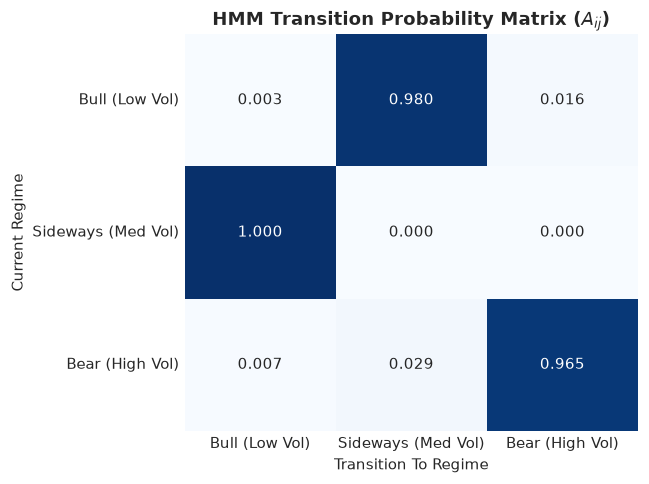

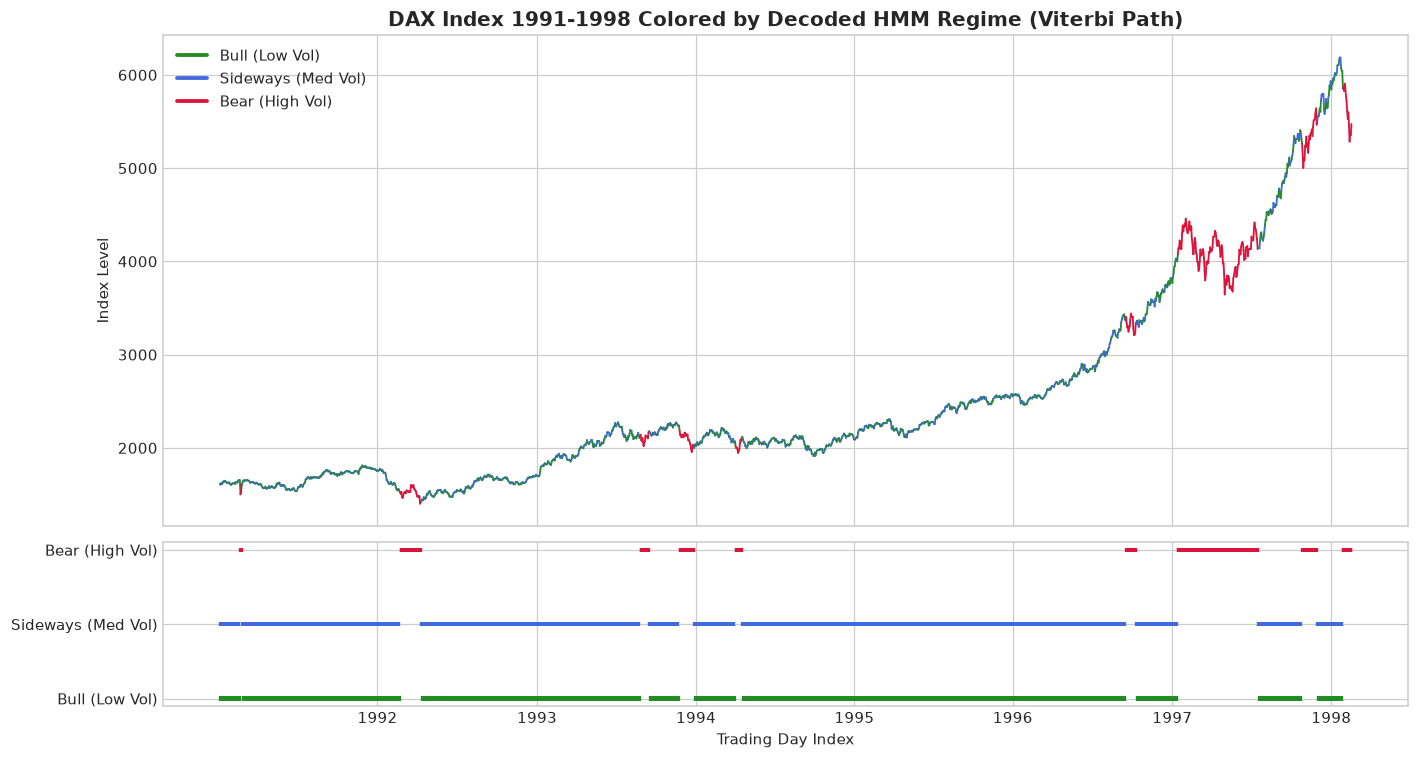

In [3]:
# ---- Transition probability matrix ----
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(sorted_transmat, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            xticklabels=regime_names, yticklabels=regime_names, cbar=False)
ax.set_title("HMM Transition Probability Matrix ($A_{ij}$)", fontweight='bold')
ax.set_xlabel("Transition To Regime")
ax.set_ylabel("Current Regime")
plt.tight_layout()
plt.show()

# ---- Viterbi-decoded regimes over the price series ----
colors = ['forestgreen', 'royalblue', 'crimson']
x = np.arange(len(prices))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Top: color every consecutive price segment by its decoded regime
for i in range(len(prices) - 1):
    ax1.plot([x[i], x[i + 1]], [prices[i], prices[i + 1]], color=colors[sorted_hidden_states[i]], lw=1.2)
for i, name in enumerate(regime_names):
    ax1.plot([], [], color=colors[i], label=name, lw=2.5)
ax1.set_title("DAX Index 1991-1998 Colored by Decoded HMM Regime (Viterbi Path)", fontsize=13, fontweight='bold')
ax1.set_ylabel("Index Level")
ax1.legend(loc='upper left')

# Bottom: raw sequence of decoded states over time
ax2.scatter(x, sorted_hidden_states, c=[colors[s] for s in sorted_hidden_states], s=8, marker='|')
ax2.set_yticks(range(n_components))
ax2.set_yticklabels(regime_names)
ax2.set_xlabel("Trading Day Index")

# Label the x-axis with years (real dates)
year_pos = np.where(dates.dt.year.diff().fillna(0).values != 0)[0]
ax2.set_xticks(year_pos)
ax2.set_xticklabels(dates.dt.year.iloc[year_pos].astype(str))

plt.tight_layout()
plt.show()
